## **Implementasi Materi Statistik Deskriptif Melalui Projek EDA**

### Kelompok 5 (B)
1. Cikal Ghifari Pamungkas (5027261017)
2. Azzka Maula Effendi (5027261062) 
3. Dimas Diki Darmawan (5027261114)


### **Latar Belakang dan Pertanyaan**

Ancaman keamanan siber terus meningkat setiap tahunnya, menargetkan berbagai sektor industri di seluruh dunia. Dataset ini menarik untuk dieksplor lebih lanjut karena tidak hanya mencatat jenis serangan, tetapi juga merekam metrik kuantitatif yang sangat penting bagi sebuah organisasi: seberapa banyak pengguna layanan yang terdampak, berapa lama waktu yang dibutuhkan untuk pulih, dan kerugian finansial yang ditimbulkan.

Melalui Exploratory Data Analysis (EDA) ini, kami ingin menjawab pertanyaan berikut menggunakan statistik deskriptif:
1. Industri apa yang paling sering menjadi korban serangan siber, dan ancaman apa yang paling mendominasi?
2. Berapa rata-rata kerugian finansial akibat insiden siber, dan seberapa besar variasinya (simpangan baku)?
3. Apakah jumlah pengguna yang terdampak memiliki banyak *outlier* (nilai ekstrem)?

In [5]:
import pandas as pd

df = pd.read_csv("Global_Cybersecurity_Threats_2015-2024.csv")
print(df.shape)
df

(3000, 10)


,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68
...,...,...,...,...,...,...,...,...,...,...
2995,UK,2021,Ransomware,Government,51.42,190694,Unknown,Social Engineering,Firewall,52
2996,Brazil,2023,SQL Injection,Telecommunications,30.28,892843,Hacker Group,Zero-day,VPN,26
2997,Brazil,2017,SQL Injection,IT,32.97,734737,Nation-state,Weak Passwords,AI-based Detection,30
2998,UK,2022,SQL Injection,IT,32.17,379954,Insider,Unpatched Software,Firewall,9



### **Penjelasan Singkat**

Satu baris pada dataset mewakili satu insiden serangan siber dengan rincian data seperti negara, tahun insiden tersebut terjadi, jenis serangan, industri yang ditargetkan, kerugian dari sisi finansial, jumlah pengguna layanan yang terdampak, pelaku dari insiden tersebut, jenis kerentanan sistem, dan mekanisme perlindungan yang dilakukan.

### **Deskripsi Data dan Kamus Data**
- **Sumber Data**            : Kaggle 
- **Link Data**              : https://www.kaggle.com/datasets/atharvasoundankar/global-cybersecurity-threats-2015-2024
- **Author**                 : Atharva Soundankar
- **Lisensi**                : CC0: Public Domain
- **Cara Pengumpulan Data**  : Berdasarkan keterangan sumbernya, data ini merupakan **data sintetis** yang dirancang untuk keperluan edukasi, penelitain, dan analisis. Data dibuat sedemikian rupa agar meniru pola dan struktur pelaporan insiden keamanan siber di dunia nyata dari tahun 2015-2024.
- **Referensi Struktur Data**: *Verizon Data Breach Investigations Report (DBIR), ENISA Threat Landscape Reports, MITRE ATT&CK Framework, CrowdStrike* dan Arsip Keamanan Siber Nasional.
- **Jumlah Baris dan Kolom**   : 3000 baris dan 10 kolom.

| Kolom | Arti | Jenis Variabel | Skala | Satuan | Contoh|
|---|---|---|---|---|---|
| **Country** | Negara dimana serangan terjadi  | Kualitatif | Nominal | -  | China | 
| **Year**  | Tahun insiden serangan terjadi  | Kuantitatif Diskrit  | Interval | Tahun  | 2018  | 
| **Attack Type** | Metode peretasan (Phising, SQL Injection, dll)  |  Kualitatif | Nominal | -  | SQL Injection  | 
| **Target Industry** | Industri yang terdampak dari serangan (Finance, Healthcare, dll) | Kualitatif | Nominal | -| Finance  | 
| **Financial Loss** | Perkiraan kerugian finansial  | Kuantitatif Kontinu | Rasio | Juta $  | \$80.53 M  | 
| **Number of Affected Users** | Jumlah data pengguna yang berhasil diretas  | Kuantitatif Diskrit  | Rasio | User  | 605895 User  |
| **Attack Source** | Pihak yang bertanggung jawab untuk insiden serangan tersebut | Kualitatif | Nominal | -  | Hacker Group  |
| **Securit Vulnerable Type** | Jenis kerentanan yang ada pada sistem | Kualitatif | Nominal | - | Weak Passwords  | 
| **Defense Mechanism Used** | Mekanisme pertahanan yang digunakan untuk mengatasi serangan | Kualitatif | Nominal | - | Firewall |
| **Response Time (Hours)** | Waktu yang dibutuhkan untuk memitigasi serangan | Kuantitatif Diskrit | Rasio | Jam | 68 Jam  | 

### **Pemeriksaan Kualitas Data**

In [7]:
import pandas as pd

df = pd.read_csv("Global_Cybersecurity_Threats_2015-2024.csv")

df.info()
print(df.isna().sum())
print("Data Dupe = ", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              3000 non-null   str    
 1   Year                                 3000 non-null   int64  
 2   Attack Type                          3000 non-null   str    
 3   Target Industry                      3000 non-null   str    
 4   Financial Loss (in Million $)        3000 non-null   float64
 5   Number of Affected Users             3000 non-null   int64  
 6   Attack Source                        3000 non-null   str    
 7   Security Vulnerability Type          3000 non-null   str    
 8   Defense Mechanism Used               3000 non-null   str    
 9   Incident Resolution Time (in Hours)  3000 non-null   int64  
dtypes: float64(1), int64(3), str(6)
memory usage: 234.5 KB
Country                                0
Year       

- **3000 non-null** = 3000 dari 3000 baris data untuk setiap kolom terisi tanpa ada kekurangan informasi.
- Dengan menghitung *summary* dari fungsi duplicated() untuk setiap data yang dibaca (df) **tidak ditemukan data dupe (0)**
- Tipe data sudah sesuai dengan jenis variabel yang ada

### **Statistik Deskriptif Variabel Numerik**
##### **3 Kolom yang diamati meliputi :**
 1.  Financial Loss 
 2.  Number of Affected Users
 3.  Incident Resolution Time (in Hours)


In [28]:
import pandas as pd

df = pd.read_csv("Global_Cybersecurity_Threats_2015-2024.csv")
kolom = df["Financial Loss (in Million $)"]
print("Mean: ",kolom.mean(),"\nMedian: ", kolom.median(), "\nModus: ", kolom.mode()[0])
print("Varians: ", kolom.var(),"\nSimpangan Baku: ", kolom.std())
print("Q1: ", kolom.quantile(0.25),"\nQ3: ",  kolom.quantile(0.75))
print("IQR: ",kolom.quantile(0.75) - kolom.quantile(0.25)) 
df.drop(columns=["Year"]).describe()

Mean:  50.49297 
Median:  50.795 
Modus:  17.99
Varians:  828.9455904092364 
Simpangan Baku:  28.791415220673617
Q1:  25.7575 
Q3:  75.63
IQR:  49.872499999999995


,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
count,3000.000000,3000.000000,3000.000000
mean,50.492970,504684.136333,36.476000
std,28.791415,289944.084972,20.570768
min,0.500000,424.000000,1.000000
25%,25.757500,255805.250000,19.000000
50%,50.795000,504513.000000,37.000000
75%,75.630000,758088.500000,55.000000
max,99.990000,999635.000000,72.000000


#### **Membandingkan kalkulasi manual (dengan rumus) dari fungsi std() dan var()**

Varians (Sampel) $$ s^2 = \frac{\sum (x_i - \bar{x})^2}{n-1} $$
Simpangan Baku (Sampel) $$ s = \sqrt {\frac{\sum (x_i - \bar{x})^2}{n-1}} $$

##### Kolom yang digunakan adalah ***Financial Loss***

In [38]:
import pandas as pd


sampel = 10
data = df["Financial Loss (in Million $)"].head(10)
n = len(data)

mean = sum(data)/n

selisihDataKuadrat = 0
for i in data:
    selisih = i - mean
    kuadrat = selisih**2
    selisihDataKuadrat += kuadrat

var = selisihDataKuadrat /(n-1)
std = var**0.5

print("Var: ", var)
print("Std: ", std)


Var:  609.6952455555555
Std:  24.692007726297906


## Ringkasan Variabel Kategorik
#####  Kolom yang digunakan adalah ***Country***

In [7]:
import pandas as pd

df = pd.read_csv("Global_Cybersecurity_Threats_2015-2024.csv")

df["Target Industry"].value_counts()
print(df["Target Industry"].value_counts(normalize=True) * 100)
print("\n")
print(df["Attack Type"].value_counts(normalize=True) * 100)

# normalize = proporsi, jumlah kejadian/3000 data

Target Industry
IT                    15.933333
Banking               14.833333
Healthcare            14.300000
Retail                14.100000
Education             13.966667
Telecommunications    13.433333
Government            13.433333
Name: proportion, dtype: float64


Attack Type
DDoS                 17.700000
Phishing             17.633333
SQL Injection        16.766667
Ransomware           16.433333
Malware              16.166667
Man-in-the-Middle    15.300000
Name: proportion, dtype: float64


Berdasarkan pemetaan frekuensi di atas, Industri ***IT*** dan jenis serangan **DDoS** merupakan industri yang paling sering muncul pada dataset (modus) dengan presentase **15,93%** dan **17,7%**. 


## **Visualisasi Data**


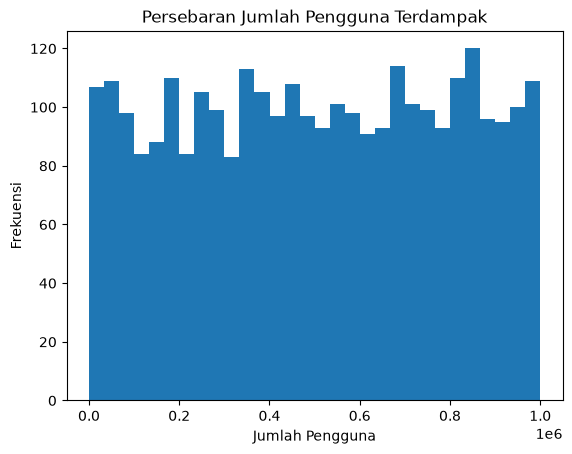

In [113]:
import matplotlib.pyplot as plt

plt.hist(df["Number of Affected Users"], bins=30)
plt.title("Persebaran Jumlah Pengguna Terdampak")
plt.xlabel("Jumlah Pengguna")
plt.ylabel("Frekuensi")
plt.show()

- ### Sebaran simetris = Uniform

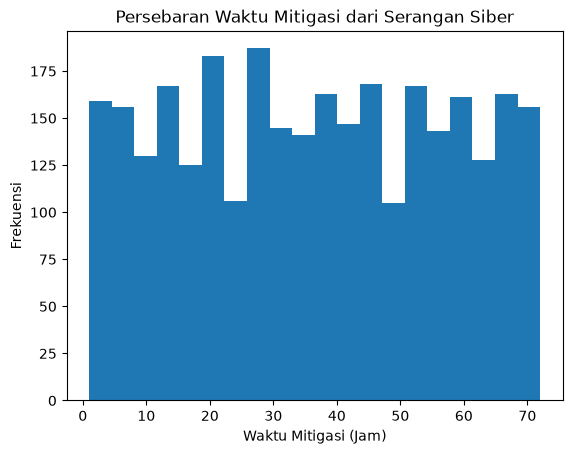

In [112]:
import matplotlib.pyplot as plt

plt.hist(df["Incident Resolution Time (in Hours)"], bins=20)
plt.title("Persebaran Waktu Mitigasi dari Serangan Siber")
plt.xlabel("Waktu Mitigasi (Jam)")
plt.ylabel("Frekuensi")
plt.show()

- ### Sebaran simetris = Uniform

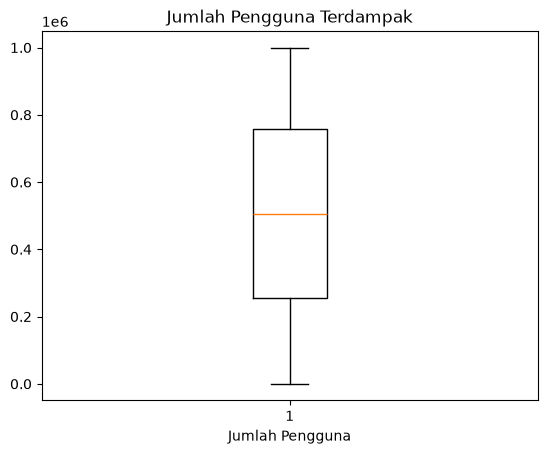

In [102]:
import matplotlib.pyplot as plt

plt.boxplot(df["Number of Affected Users"])
plt.title("Jumlah Pengguna Terdampak")
plt.xlabel("Jumlah Pengguna")
plt.show()

- ### Berdasarkan Boxplot, kolom *Number of Affected Users* tidak memiliki nilai ekstrem

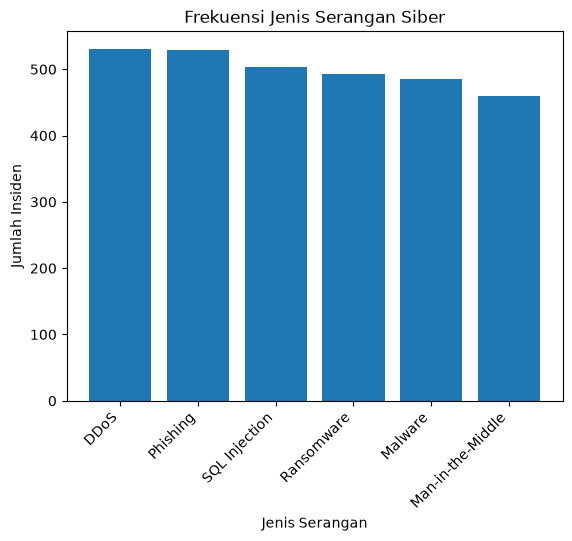

In [110]:
import matplotlib.pyplot as plt

jumlah_serangan = df["Attack Type"].value_counts()

x = jumlah_serangan.index
y = jumlah_serangan.values
plt.bar(x,y)


plt.title("Frekuensi Jenis Serangan Siber")
plt.xlabel("Jenis Serangan")
plt.ylabel("Jumlah Insiden")
plt.xticks(rotation=45, ha="right")

plt.show()

In [116]:
df.groupby("Attack Type")["Incident Resolution Time (in Hours)"].median()

Attack Type
DDoS                 35.0
Malware              36.0
Man-in-the-Middle    36.0
Phishing             35.0
Ransomware           38.0
SQL Injection        37.0
Name: Incident Resolution Time (in Hours), dtype: float64

Dari perbandingan median anterkategori jenis serangan, ***Ransomware*** terbukti menjadi jenis serangan dengan waktu pemulihan paling lama, yakni mencapai **38 jam**. Sedangkan untuk ***DDOS*** dan ***Phishing*** memiliki waktu mitigasi yang relatif lebih cepat dengan median **35 jam**.

## Kesimpulan

1. **Jawaban Pertanyaan Analisis (Berdasarkan Sel 2)**
- Berdasarkan perhitungan frekuensi data kategorik, sektor industri yang paling sering menjadi korban serangan siber adalah **IT**. Sementara itu, jenis ancaman yang paling mendominasi keseluruhan insiden adalah **DDoS**.


- Rata-rata kerugian finansial yang ditimbulkan akibat insiden siber mencapai **50.49 juta Dolar**. Data ini memiliki simpangan baku (standar deviasi) sebesar 24,69 juta Dolar, yang menunjukkan seberapa jauh variasi tebaran angka kerugian finansial tersebut menyimpang dari nilai rata-ratanya.

- Berdasarkan pengujian visual menggunakan Boxplot, jumlah pengguna terdampak terbukti tidak memiliki nilai ekstrem (outlier). Data terdistribusi secara seragam (uniform) dari angka mendekati 0 hingga batas maksimum 1.000.000 pengguna.

2. **Temuan Paling Menarik**
- Keseragaman Data yang Tidak Umum: Variabel seperti waktu mitigasi dan jumlah pengguna terdampak memiliki bentuk distribusi seragam (uniform) tanpa satu pun outlier. 

- Selisih Waktu Penanganan yang Sempit: Waktu penanganan antar jenis serangan hanya terpaut sangat tipis (1–3 jam pada nilai median).

- Konsistensi Dampak Finansial: Variasi atau simpangan baku (standar deviasi) dari kerugian finansial berada di angka **24,69 juta Dolar**. Mengingat angkanya mewakili jutaan Dolar dalam skala global, sebaran ini menunjukkan bahwa mayoritas insiden siber dalam dataset ini menghasilkan nominal kerugian yang saling berdekatan dan stabil, tanpa adanya anomali kerugian ekstrem (kebangkrutan total) yang sering terjadi di dunia nyata.

3. **Keterbatasan Data**
- Sifat Data Sintetis (Buatan): Karena dataset ini di-generate secara sintetis, hasil distribusinya terlalu rapi dan merata secara matematis.
4. **Ide Pertanyaan Lanjutan (Untuk Proyek Akhir)**
- Apakah ada industri spesifikyang menghasilkan rata-rata kerugian finansial jauh lebih tinggi dibandingkan industri lain?

- Apakah variabel negara memengaruhi probabilitas munculnya *Attack Type* tertentu?

| Alat | Dipakai untuk | Yang kami pelajari |
| :--- | :--- | :--- |
| Gemini AI | Menanyakan penjelasan kode `value_counts(normalize=True) * 100` | Memahami cara kerja parameter `normalize` untuk menghitung proporsi persentase pada data kategorik. |
| Gemini AI | Menentukan jumlah `bins` histogram untuk kolom Tahun (2015-2024) | Mengetahui bahwa data diskret dengan rentang 10 tahun paling optimal menggunakan `bins=10` agar tiap batang mewakili tepat 1 tahun. |
| Gemini AI | Merapikan label sumbu X yang bertumpuk pada Bar Chart | Belajar menggunakan `plt.xticks()` dengan parameter `rotation=45` dan `ha="right"` agar teks miring dan bersandar rapi di bawah grafik. |
| Gemini AI | Menanyakan perbedaan bentuk grafik Histogram dan Diagram Batang | Memahami kaidah statistik: Histogram batangnya menempel karena datanya kontinu, sedangkan Bar Chart memiliki jarak (gap) karena datanya kategorik. |
| Gemini AI | Mengatasi error `AttributeError: 'Series' object has no attribute 'bar'` | Menyadari perbedaan sintaks objek: grafik harus dipanggil menggunakan fungsi Matplotlib (`plt.bar()`), bukan ditempel langsung pada objek *Series* Pandas. |
| Gemini AI | Mencari tahu penyebab fungsi `.median()` error saat digunakan pada `Attack Type` | Memahami bahwa perhitungan statistik seperti median atau rata-rata hanya bisa dikenakan pada kolom numerik, bukan teks (kategorik). |
| Gemini AI | Meminta panduan cara membaca bentuk kemiringan data (*skewness*) | Belajar mengidentifikasi apakah distribusi data simetris, seragam, atau miring berdasarkan bentuk visual grafik dan perbandingan nilai rata-rata (*Mean*) versus nilai tengah (*Median*). |